# TP 2 - Cambio de métrica de enfoque

In [1]:
import cv2 as cv
import time
from pathlib import Path
import util as utils
import numpy as np

In [2]:
video_path = 'material/focus_video.mov'
output_analysis_path = 'material/lap2'

## Modified Laplacian (LAP2)

Para esta parte del trabajo utilizaremos el algorítmo Modified Laplacian (LAP2). Se eligió el mismo dado los buenos resultados que el paper Analysis of focus measure operators in shape-from-focus señala.

Extraigo del mismo:

_The conducted experiments show that the family of Laplacian- based operators have the best overall performance at normal imaging conditions (i.e., without addition of noise, contrast reduction or image saturation). The image Laplacian is a discrete approximation of the second derivative of the image and high- lights regions with rapid changes in intensities. This makes it suitable for detecting changes in focus._

Estos operadores trabajan en el dominio espacial, es decir, directamente sobre los valores de los píxeles de la imagen, como están dispuestos en la matriz de la imagen.

A muy grandes rasgos LAP2 toma cada píxel, mira su entorno inmediato, aplica una máscara (filtro) y calcula cuánto “cambia” la imagen ahí. 


CSV exportado a: material/lap2/fm.csv
Gráfico guardado como: material/lap2/fm.png


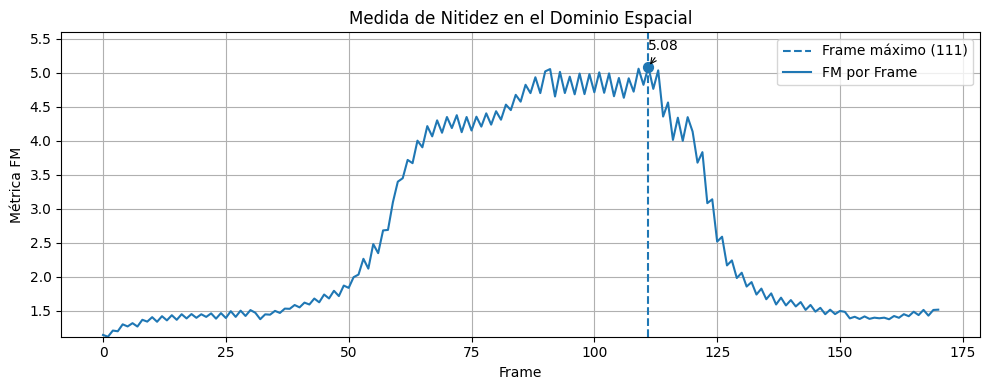

Mostrando los 3 frames con menor FM:


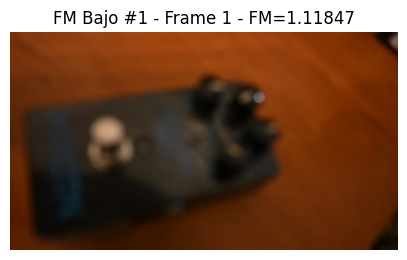

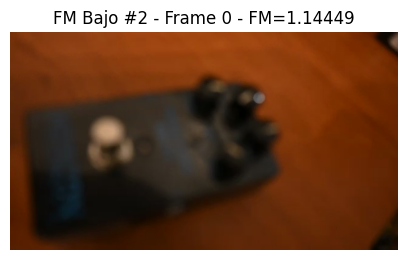

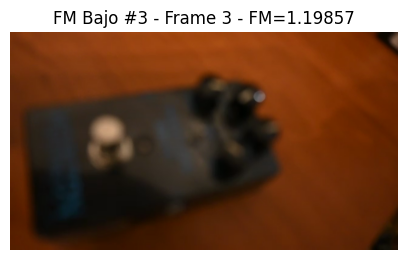

Mostrando los 3 frames con mayor FM:


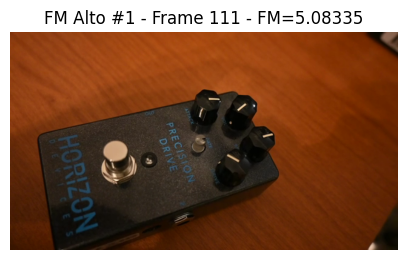

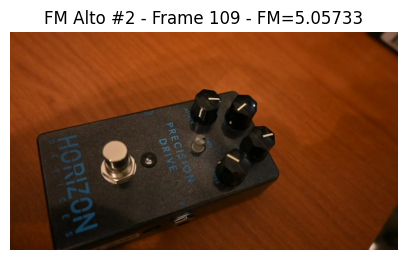

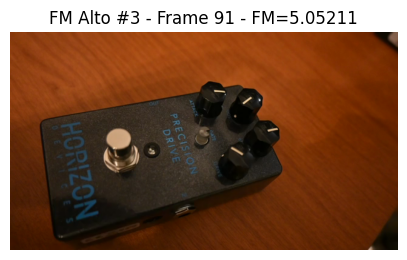

In [3]:
fm_values, frames_processed = utils.process_video(video_path, algorithm=utils.measure_image_quality_lap2)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, output_analysis_path, plot_title="Medida de Nitidez en el Dominio Espacial")
    utils.show_extreme_frames(fm_values, frames_processed, n=3)

En primera instancia podemos observar un gráfico similar al obtenido por el algoritmo analizado en la parte 1, además de observar frames cercanos o incluso los mismos a los obtenidos en aquella oportunidad.

### ROI = 0.05

CSV exportado a: material/lap2/fm_roi_0.05.csv
Gráfico guardado como: material/lap2/fm_roi_0.05.png


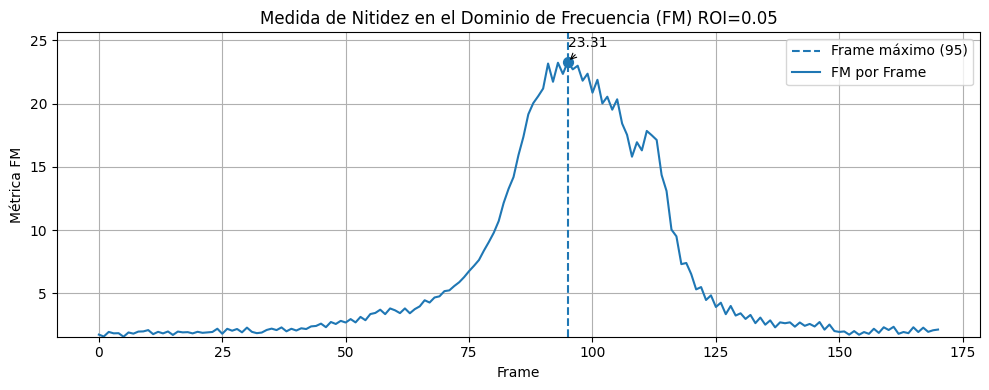

Mostrando los 1 frames con menor FM:


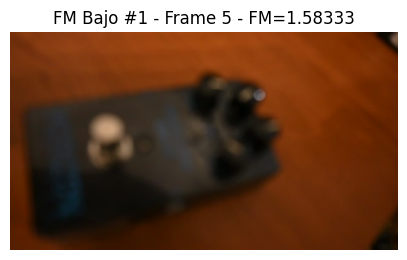

Mostrando los 1 frames con mayor FM:


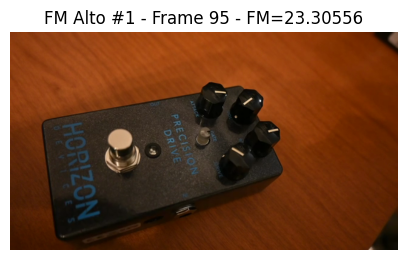

In [4]:
fm_values, frames_processed = utils.process_video_with_roi(video_path, 0.05, algorithm=utils.measure_image_quality_lap2)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, output_analysis_path, roi=0.05, plot_title="Medida de Nitidez en el Dominio de Frecuencia (FM) ROI=0.05")
    utils.show_extreme_frames(fm_values, frames_processed, n=1)

En esta oportunidad, para un ROI del 5% del frame, el gráfico cambia drásticamente, reduciéndose mucho el tiempo del video donde se obtiene un buen puntaje de enfoque.

### ROI = 0.01

CSV exportado a: material/lap2/fm_roi_0.10.csv
Gráfico guardado como: material/lap2/fm_roi_0.10.png


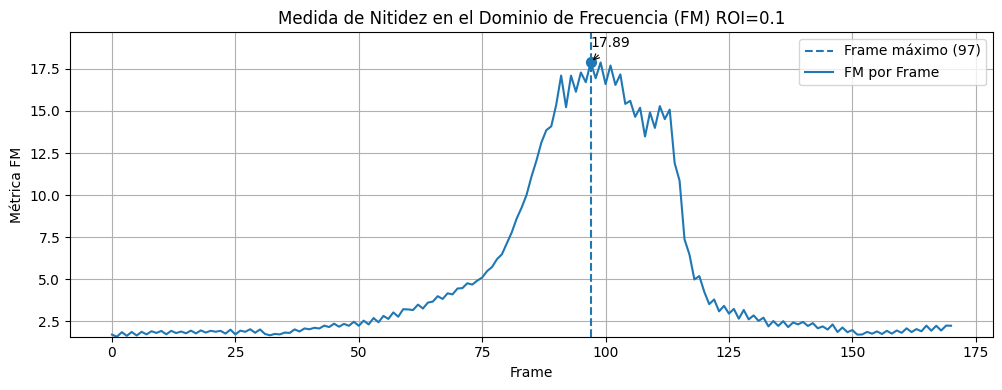

Mostrando los 1 frames con menor FM:


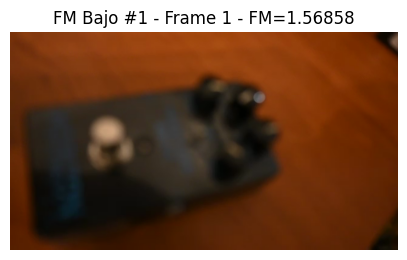

Mostrando los 1 frames con mayor FM:


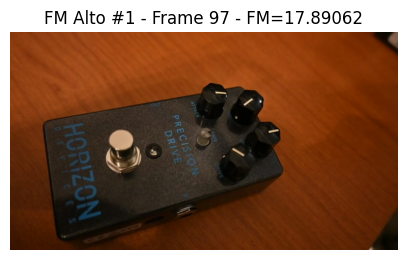

In [5]:
fm_values, frames_processed = utils.process_video_with_roi(video_path, 0.1, algorithm=utils.measure_image_quality_lap2)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, output_analysis_path, roi=0.1, plot_title="Medida de Nitidez en el Dominio de Frecuencia (FM) ROI=0.1")
    utils.show_extreme_frames(fm_values, frames_processed, n=1)

Analizamos tiempos de ejecución:

In [7]:
roi_values = [0.05, 0.1, 1.0]
repeticiones = 5  # Número de veces que se repite cada medición
tiempos_promedio = {}

for roi_pct in roi_values:
    tiempos = []
    for _ in range(repeticiones):
        start_time = time.time()
        _ = utils.process_video_with_roi(video_path, roi_pct, algorithm=utils.measure_image_quality_lap2)
        tiempo = time.time() - start_time
        tiempos.append(tiempo)
    promedio = np.mean(tiempos)
    tiempos_promedio[roi_pct] = promedio

# Mostrar resultados
for roi, t_prom in tiempos_promedio.items():
    print(f"ROI {roi:.2f} → Tiempo promedio: {t_prom:.4f} segundos en {repeticiones} ejecuciones")

ROI 0.05 → Tiempo promedio: 0.0851 segundos en 5 ejecuciones
ROI 0.10 → Tiempo promedio: 0.0864 segundos en 5 ejecuciones
ROI 1.00 → Tiempo promedio: 0.4923 segundos en 5 ejecuciones


Los tiempos de ejecución son muy similares a los obtenidos por el algoritmo previo.

### Unsharp Mask

Haremos uso de la técnica de unsharp mask para expandir la zona de enfoque.

La misma realza los bordes aparentando mayor nitidez en los frames. Para ello desenfoca la imágen, luego resta esa versión desenfocada a la original para obtener los detalles y por último suma esos detalles a la imágen original.

Como consecuencia logra que los bordes se perciban con mayor contraste.  

La formula es: sharpened = original + amount * (original - blurred)

CSV exportado a: material/lap2/fm.csv
Gráfico guardado como: material/lap2/fm.png


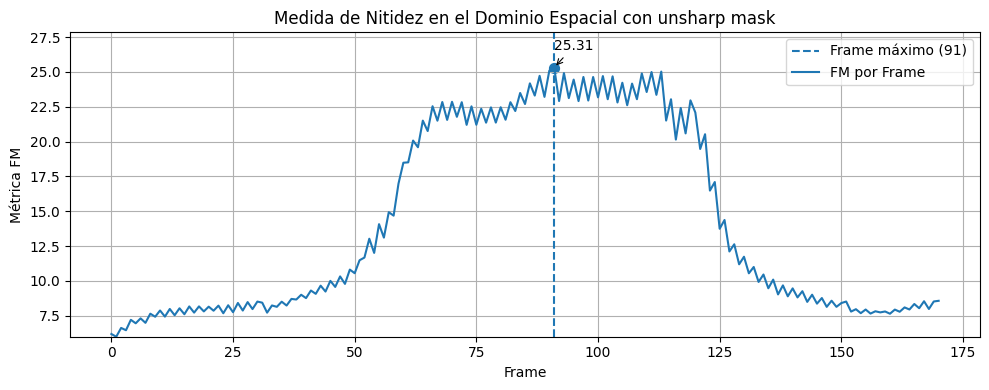

In [6]:
fm_values, frames_processed = utils.process_video(video_path, algorithm=utils.measure_image_quality_lap2, use_unsharp_mask=True)

if fm_values is not None:
    utils.export_and_plot_fm(fm_values, output_analysis_path, plot_title="Medida de Nitidez en el Dominio Espacial con unsharp mask")

Aunque los frames más enfocados siguen correspondiendo a la misma región temporal del video, la aplicación de unsharp masking elevó significativamente los valores de la métrica de enfoque en todos los cuadros. 

Esto sugiere que el realce afectó de manera uniforme a la percepción de nitidez. En particular, el frame con mayor enfoque pasó de un valor FM de 5.08 en la versión original a 25.31 tras aplicar el filtro, ampliando la zona considerada como "enfocada" por el operador.

Este comportamiento indica que unsharp masking puede ser útil no solo para destacar el frame más nítido, sino también para mejorar la sensibilidad general de los operadores espaciales, como LAP2, al reforzar detalles que de otro modo pasarían desapercibidos en regiones levemente desenfocadas.

A continuación presento una comparación entre dos frames levemente enfocados. El primero es el original mientras que al segundo se le aplicó unsharp mask. 

Se puede notar a simple vista que los bordes de la segunda imágen se ven de forma más nitida. Por ejemplo en las primeras letras que aparecen en la superficie del pedal dónde se lee "precision drive"

In [19]:
fm_values_with_unsharp_mask, frames_processed_with_unsharp_mask = utils.process_video(video_path, algorithm=utils.measure_image_quality_lap2, use_unsharp_mask=True, return_gray_frame=True)

fm_values, frames_processed = utils.process_video(video_path, algorithm=utils.measure_image_quality_lap2, use_unsharp_mask=False, return_gray_frame=True)

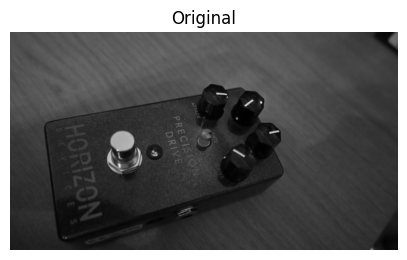

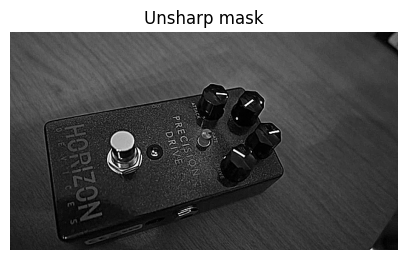

In [20]:
utils.show_image(frames_processed[100], 'Original')
utils.show_image(frames_processed_with_unsharp_mask[100], 'Unsharp mask')

Algo que nos llamó la atención de aplicar unsharp masking es que algunos frames visiblemente desenfocados alcanzan valores de la métrica superiores a imágenes originalmente nítidas. 

Por ejemplo, el frame 25, claramente fuera de foco, obtuvo un valor FM de 7.5 tras el realce, superando al frame 111 sin filtro (5.08), que está visualmente más enfocado. 

Esto sugiere que esta técnica puede inflar artificialmente la métrica de enfoque, lo que pone en evidencia una limitación de los operadores basados en derivadas como LAP2: no distinguen entre nitidez real y bordes amplificados.

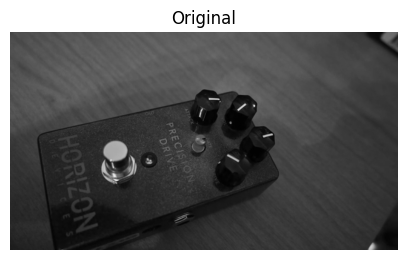

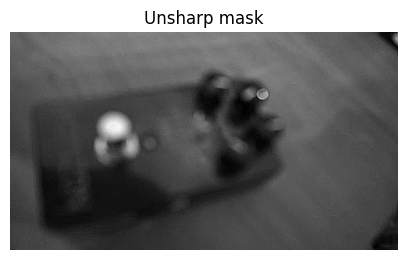

In [22]:
utils.show_image(frames_processed[111], 'Original')
utils.show_image(frames_processed_with_unsharp_mask[25], 'Unsharp mask')